In [ ]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 42.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import data_utils_clean
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer,MissingIndicator
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,MinMaxScaler,PowerTransformer,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [ ]:
!pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.2/261.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.3 MB/s eta 0:00:00


In [ ]:
import dagshub
dagshub.init(repo_owner='sneha12603', repo_name='Delivery-time-prediction', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=88cafc01-458b-435a-bb25-ca4dbdeabe76&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=c1d0a5a473b39d8ca01cc9fbbde39bf87fcd30ba57064bc84441a3deb4e0c102




Output()

Accessing as sneha12603

Initialized MLflow to track repo "sneha12603/Delivery-time-prediction"

Repository sneha12603/Delivery-time-prediction initialized!

In [ ]:
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.2/676.2 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 14.9 MB/s eta 0:00:00


In [ ]:
import mlflow

In [ ]:
#set the tracking server
mlflow.set_tracking_uri("https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow")

In [ ]:
mlflow.set_experiment("Exp 3 - Model Selection")

<Experiment: artifact_location='mlflow-artifacts:/211af52234874a0181ac400ce58e045a', creation_time=1752344614835, experiment_id='2', last_update_time=1752344614835, lifecycle_stage='active', name='Exp 3 - Model Selection', tags={}>

In [ ]:
#load the data
from sklearn import set_config

set_config(transform_output="pandas")

In [ ]:
df = pd.read_csv("swiggy.csv")
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [ ]:
#clean the data
data_utils_clean.perform_data_cleaning(df)

In [ ]:
#load the cleaned data
df = pd.read_csv('swiggy_cleaned.csv')

In [ ]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [ ]:
#drop columns not required for model output
columns_to_drop = ['restaurant_longitude',
                   'order_time_hour', # This column was dropped during cleaning
                   'city_name', # This column was dropped during cleaning
                   'order_day_of_week', # This column was dropped during cleaning
                   'order_month' # This column was dropped during cleaning
                   ]

df.drop(columns=columns_to_drop,inplace=True)
df

,rider_id,age,ratings,restaurant_latitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,...,multiple_deliveries,festival,city_type,time_taken,order_day,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,22.765049,75.912471,2022-03-19,sunny,high,2,...,0.0,no,urban,24,19,1,15.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,13.043041,77.813237,2022-03-25,stormy,jam,2,...,1.0,no,metropolitian,33,25,0,5.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,12.924264,77.688400,2022-03-19,sandstorms,low,0,...,1.0,no,urban,26,19,1,15.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,11.053669,77.026494,2022-04-05,sunny,medium,0,...,1.0,no,metropolitian,21,5,0,10.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,13.012793,80.289982,2022-03-26,cloudy,high,1,...,1.0,no,metropolitian,30,26,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,26.912328,75.804257,2022-03-24,windy,high,1,...,0.0,no,metropolitian,32,24,0,10.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,2022-02-16,windy,jam,0,...,1.0,no,metropolitian,36,16,0,15.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,13.052394,80.272439,2022-03-11,cloudy,low,1,...,0.0,no,metropolitian,16,11,0,15.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,11.041753,77.026241,2022-03-07,cloudy,high,0,...,1.0,no,metropolitian,26,7,0,5.0,afternoon,6.232393,medium


In [ ]:
#check for missing values
df.isna().sum()

,0
rider_id,0
age,1854
ratings,1908
restaurant_latitude,3630
delivery_latitude,3630
delivery_longitude,3630
order_date,0
weather,525
traffic,510
vehicle_condition,0


In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

<Axes: >

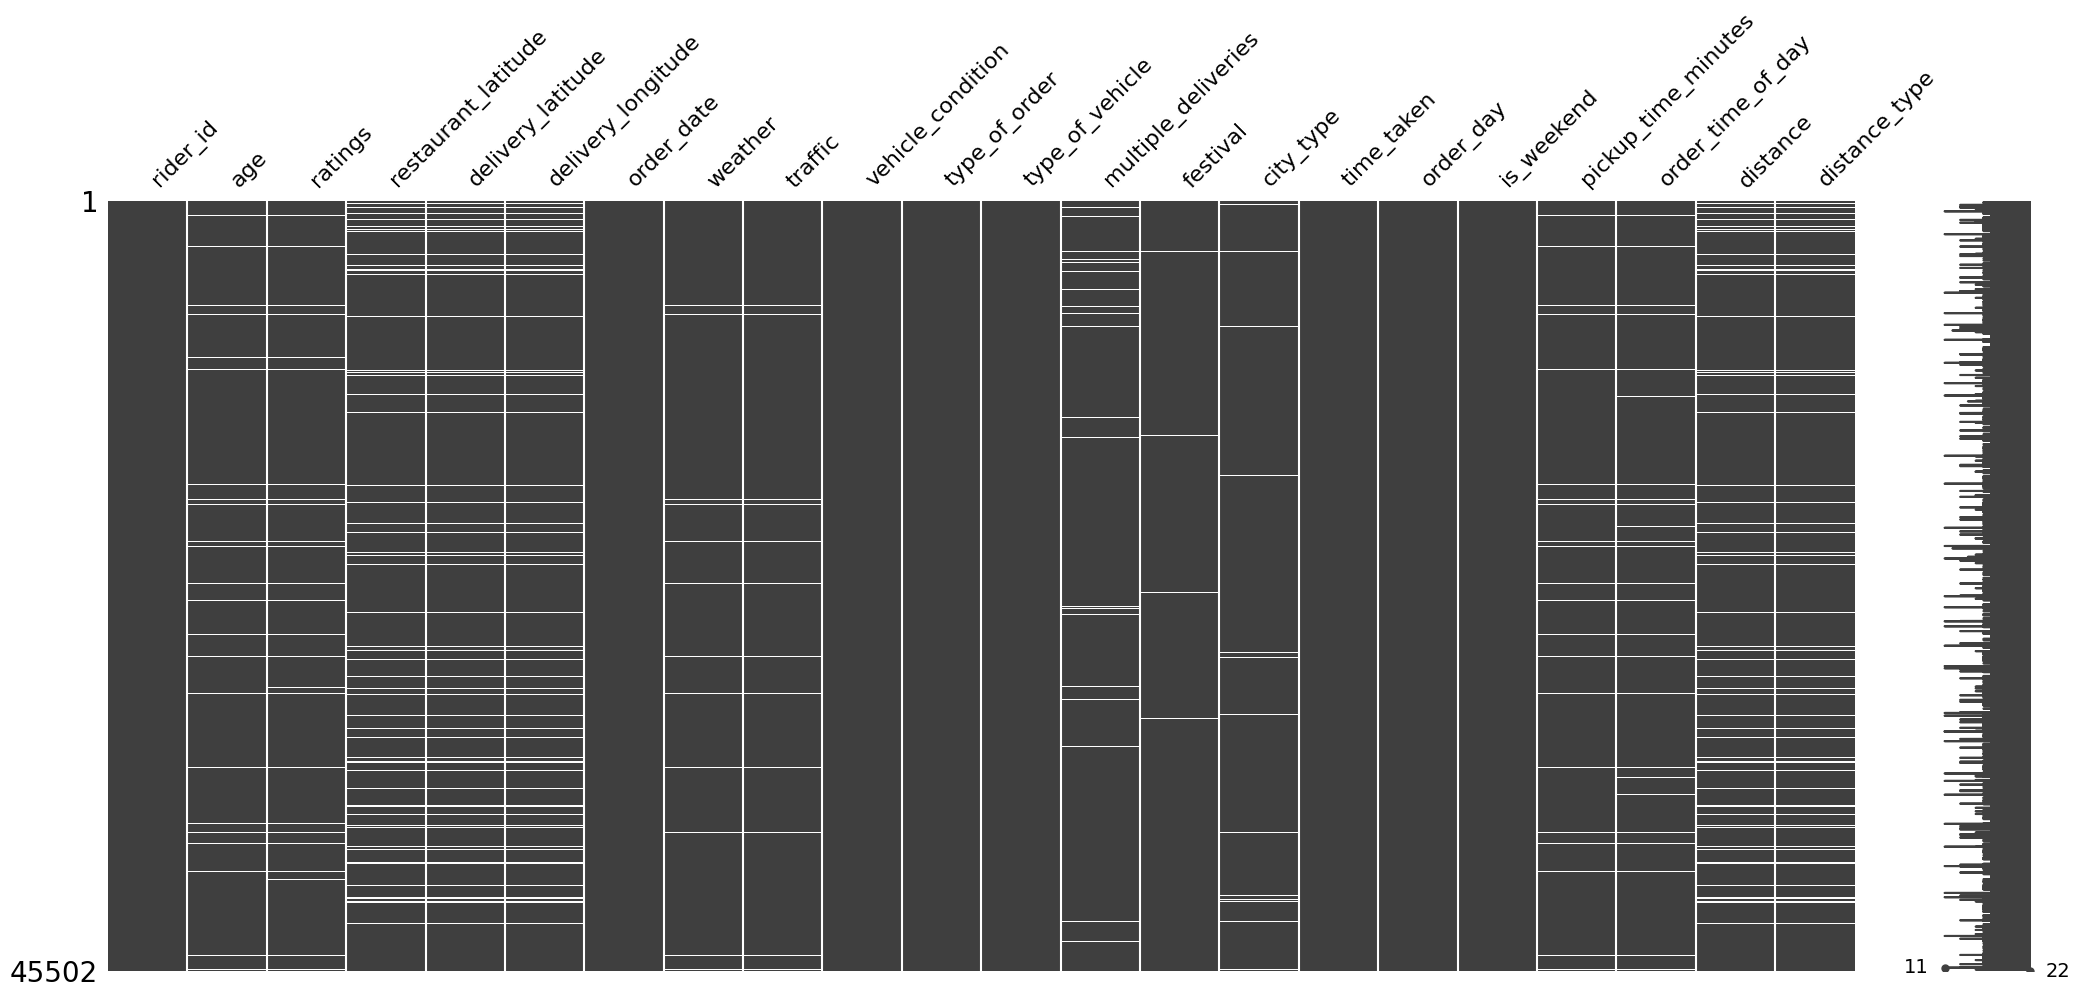

In [ ]:
import missingno as msno
msno.matrix(df)

In [ ]:
#column that have missing values
missing_cols = (
    df.isna().any(axis=0).loc[lambda x: x].index
)

missing_cols

Index(['age', 'ratings', 'restaurant_latitude', 'delivery_latitude',
       'delivery_longitude', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [ ]:
#drop missing values
temp_df = df.copy().dropna()

In [ ]:
#split into X and y
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [ ]:
X

,rider_id,age,ratings,restaurant_latitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,...,type_of_vehicle,multiple_deliveries,festival,city_type,order_day,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,22.765049,75.912471,2022-03-19,sunny,high,2,...,motorcycle,0.0,no,urban,19,1,15.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,13.043041,77.813237,2022-03-25,stormy,jam,2,...,scooter,1.0,no,metropolitian,25,0,5.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,12.924264,77.688400,2022-03-19,sandstorms,low,0,...,motorcycle,1.0,no,urban,19,1,15.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,11.053669,77.026494,2022-04-05,sunny,medium,0,...,motorcycle,1.0,no,metropolitian,5,0,10.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,13.012793,80.289982,2022-03-26,cloudy,high,1,...,scooter,1.0,no,metropolitian,26,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,RANCHIRES16DEL01,35.0,4.2,23.371292,23.481292,85.437872,2022-03-08,windy,jam,2,...,motorcycle,1.0,no,metropolitian,8,0,10.0,night,16.600272,very_long
45497,JAPRES04DEL01,30.0,4.8,26.902328,26.912328,75.804257,2022-03-24,windy,high,1,...,motorcycle,0.0,no,metropolitian,24,0,10.0,morning,1.489846,short
45499,CHENRES08DEL03,30.0,4.9,13.022394,13.052394,80.272439,2022-03-11,cloudy,low,1,...,scooter,0.0,no,metropolitian,11,0,15.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,11.041753,77.026241,2022-03-07,cloudy,high,0,...,motorcycle,1.0,no,metropolitian,7,0,5.0,afternoon,6.232393,medium


In [ ]:
#train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("The size of train data is",X_train.shape)
print("The size of test data is",X_test.shape)

The size of train data is (30156, 21)
The size of test data is (7539, 21)


In [ ]:
X_train.isna().sum()

,0
rider_id,0
age,0
ratings,0
restaurant_latitude,0
delivery_latitude,0
delivery_longitude,0
order_date,0
weather,0
traffic,0
vehicle_condition,0


In [ ]:
#transorm target column
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [ ]:
missing_cols

Index(['age', 'ratings', 'restaurant_latitude', 'delivery_latitude',
       'delivery_longitude', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [ ]:
#percentage of rows in dat having missing values
(
    X_train.isna().any(axis=1).mean().round(2)*100
)

np.float64(0.0)

***Pre Processing Pipeline***

In [ ]:
num_cols = ["age","ratings","pickup_times","distance"]

nominal_cat_cols = ['weather',
                   'type_of_order',
                   'type_of_vehicle',
                   'festival',
                   'city_type',
                   'is_weekend',
                   'order_time_of_day']

ordinal_cat_cols = ['traffic','distance_type']

In [ ]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [ ]:
X_train.isna().sum()

,0
rider_id,0
age,0
ratings,0
restaurant_latitude,0
delivery_latitude,0
delivery_longitude,0
order_date,0
weather,0
traffic,0
vehicle_condition,0


In [ ]:
#do basic preprocessing
num_cols = ['age','ratings','pickup_time_minutes','distance']

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle','festival',
                    'city_type','is_weekend',
                    'order_time_of_day']

ordinal_cat_cols = ['traffic','distance_type']

In [ ]:
#genertate order for ordinal encoding
traffic_order = ['low','medium','high','jam']

distance_type_order = ['short','medium','long','very_long']

In [ ]:
#unique categories in ordinal column
for col in ordinal_cat_cols:
  print(col,X_train[col].unique())

traffic ['jam' 'medium' 'high' 'low']
distance_type ['medium' 'short' 'long' 'very_long']


In [ ]:
#build a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("scale",MinMaxScaler(),num_cols),
    ("nominal_encode",OneHotEncoder(drop='first',handle_unknown='ignore',
                                    sparse_output=False),nominal_cat_cols),
    ("ordinal_encode",OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                     encoded_missing_value = -999,
                                     handle_unknown='use_encoded_value',
                                     unknown_value=-1),ordinal_cat_cols)

],remainder='drop',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor

,transformers,"[('scale', ...), ('nominal_encode', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,False
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [ ]:

#build the pipeline
processing_pipeline = Pipeline(steps=[
    ("preprocess",preprocessor)

])

In [ ]:
#data preprocessing
X_train_trans = processing_pipeline.fit_transform(X_train)
X_test_trans = processing_pipeline.transform(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,type_of_vehicle_scooter,festival_yes,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 10.4 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error

In [ ]:
def objective(trial):
  with mlflow.start_run(nested=True):
    model_name = trial.suggest_categorical("model",["SVM","RF","KNN","GB","XGB","LGBM"])

    if model_name == "SVM":
      kernel_svm = trial.suggest_categorical("kernal_svm",["linear","ploy","rbf"])
      if kernel_svm == "linear":
        c_linear = trial.suggest_float("c_linear",0,10)
        model = SVR(C=c_linear,kernel="linear")

      elif kernel_svm == "poly":
        c_poly = trial.suggest_float("c_poly",0,10)
        degree_poly = trial.suggest_int("degree_poly",1,5)
        model = SVR(C=c_poly,degree = degree_poly,
                    kernel="rbf")

      else:
        c_rbf = trial.suggest_float("c_rbf",0,100)
        gamma_rbf = trial.suggest_float("gamma_rbf",0,10)
        model = SVR(C=c_rbf,gamma = gamma_rbf,
                    kernel="rbf")

    elif model_name == "RF":
      n_estimators_rf = trial.suggest_int("n_estimators_rf",10,200)
      max_depth_rf = trial.suggest_int("max_depth_rf",2,20)
      model = RandomForestRegressor(n_estimators=n_estimators_rf,
                                    max_depth=max_depth_rf,
                                    n_jobs=-1)
    elif model_name == "GB":
      n_estimators_gb = trial.suggest_int("n_estimators_gb",10,200)
      learning_rate_gb = trial.suggest_float("learning_rate_gb",0,1)
      max_depth_gb = trial.suggest_int("max_depth_gb",2,20)
      model = GradientBoostingRegressor(n_estimators=n_estimators_gb,
                                        learning_rate = learning_rate_gb,
                                        max_depth = max_depth_gb,
                                        random_state=42)


    elif model_name == "KNN":
      n_neighbors_knn = trial.suggest_int("n_neighbors_knn",1,25)
      weights_knn = trial.suggest_categorical("weights_knn",["uniform","distance"])
      model = KNeighborsRegressor(n_neighbors=n_neighbors_knn,
                                  weights=weights_knn,n_jobs=-1)


    elif model_name == "XGB":
      n_estimators_xgb = trial.suggest_int("n_estimators_xgb",10,200)
      learning_rate_xgb = trial.suggest_float("learning_rate_xgb",0.1,0.5)
      max_depth_xgb = trial.suggest_int("max_depth_xgb",2,20)
      model = XGBRegressor(n_estimators=n_estimators_xgb,
                         learning_rate = learning_rate_xgb,
                         max_depth = max_depth_xgb,
                         random_state=42,
                         n_jobs=-1)

    elif model_name == "LGBM":
     n_estimators_lgbm = trial.suggest_int("n_estmators_lgbm",10,200)
     learning_rate_lgbm = trial.suggest_float("learning_rate_lgbm",0.1,0.5)
     max_depth_lgbm = trial.suggest_int("max_depth_lgbm",2,20)
     model = LGBMRegressor(n_estimators=n_estimators_lgbm,
                           learning_rate=learning_rate_lgbm,
                           max_depth=max_depth_lgbm,
                           random_state=42)


    #train the model
    model.fit(X_train_trans,y_train_pt.values.ravel())

    #log model params
    mlflow.log_params(model.get_params())

    #get the predictions
    y_pred_train = model.predict(X_train_trans)
    y_pred_test = model.predict(X_test_trans)

    #get the actual prediction values
    y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
    y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

    #calculate the error
    error = mean_absolute_error(y_test,y_pred_test_org)

    #log model name
    mlflow.log_param("model",model_name)

    #log error
    mlflow.log_metric("MAE",error)

    return error

In [ ]:
#create optuna study
study = optuna.create_study(direction="minimize",study_name="model_selection")

with mlflow.start_run(run_name="Best Model") as parent:
  study.optimize(objective,n_trials=30,n_jobs=-1)

  #log the best parameters
  mlflow.log_params(study.best_params)

  #log the best score
  mlflow.log_metric("best_score",study.best_value)

[I 2025-07-20 23:02:31,036] A new study created in memory with name: model_selection
[I 2025-07-20 23:02:35,885] Trial 1 finished with value: 3.5334291528546844 and parameters: {'model': 'LGBM', 'n_estmators_lgbm': 188, 'learning_rate_lgbm': 0.10460112035618892, 'max_depth_lgbm': 11}. Best is trial 1 with value: 3.5334291528546844.


🏃 View run smiling-goose-516 at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2/runs/ad81cc9124134aa7b794342edeb89ff5
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2


[I 2025-07-20 23:03:12,302] Trial 2 finished with value: 4.332088610988564 and parameters: {'model': 'GB', 'n_estimators_gb': 161, 'learning_rate_gb': 0.8727127910372433, 'max_depth_gb': 6}. Best is trial 1 with value: 3.5334291528546844.


🏃 View run fortunate-panda-113 at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2/runs/f65839bef961408993208a82d607352b
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2


[I 2025-07-20 23:03:15,665] Trial 3 finished with value: 4.236561871365085 and parameters: {'model': 'RF', 'n_estimators_rf': 30, 'max_depth_rf': 6}. Best is trial 1 with value: 3.5334291528546844.


...

🏃 View run fun-doe-939 at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2/runs/268ee50944714edba2ae0e14a8f5d26c
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2


[I 2025-07-20 23:26:41,753] Trial 28 finished with value: 6.838267019538244 and parameters: {'model': 'GB', 'n_estimators_gb': 20, 'learning_rate_gb': 0.005742374959108787, 'max_depth_gb': 20}. Best is trial 1 with value: 3.5334291528546844.


🏃 View run welcoming-rook-805 at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2/runs/2333b94991af40d99b415afe3302a79a
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2


[I 2025-07-20 23:26:43,770] Trial 29 finished with value: 3.916149139404297 and parameters: {'model': 'XGB', 'n_estimators_xgb': 193, 'learning_rate_xgb': 0.28566421566806277, 'max_depth_xgb': 2}. Best is trial 1 with value: 3.5334291528546844.


🏃 View run Best Model at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2/runs/3147162382324d0f8b6eafbcf93b6943
🧪 View experiment at: https://dagshub.com/sneha12603/Delivery-time-prediction.mlflow/#/experiments/2


In [ ]:
study.best_value

3.5334291528546844

In [ ]:
lgbm_params = {
    "n_estimators":151,
    "learning_rate":0.14553773585462942,
    "max_depth":20
}

In [ ]:
#train the model on best parameters
lgbm = LGBMRegressor(**lgbm_params)
lgbm.fit(X_train_trans,y_train_pt.values.ravel())


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 345
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 23
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,20
,learning_rate,0.14553773585462942
,n_estimators,151
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
#get the predictions
y_pred_train = lgbm.predict(X_train_trans)
y_pred_test = lgbm.predict(X_test_trans)



In [ ]:
#get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))


In [ ]:
from sklearn.metrics import mean_absolute_error,r2_score

print(f"train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"test score is {r2_score(y_test,y_pred_test_org):.2f}")

In [ ]:
print(f"train error is {mean_absolute_error(y_train,y_pred_train_org):.2f}minutes")
print(f"test error is {mean_absolute_error(y_test,y_pred_test_org):.2f}minutes")


In [ ]:
#dataframe of results
study.trials_dataframe()

In [ ]:
#model frequency
study.trials_dataframe()['params_model'].value_counts()

In [ ]:
#avg scores for all tested models
study.trials_dataframe().groupby("params_model")['value'].mean().sort_values()

In [ ]:
from sklearn.compose import TransformedTargetRegressor
model = TransformedTargetRegressor(regressor=lgbm,transformer=pt)

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,X_train_trans,y_train,scoring="neg_mean_absolute_error",cv=5,n_jobs=-1)
scores

In [ ]:
#means score
-scores.mean()

In [ ]:
#optimization history plot
optuna.visualization.plot_optimization_history(study)

In [ ]:
#partial co-ordinate plot
optuna.visualization.plot_parallel_coordinate(study,params=["model"])